# Flower Species Classification with Iris Dataset

> The main goal of this project is to analyze the Iris dataset and apply machine learning algorithms to correctly classify the flower species based on their measures.

## Importing modules

In [54]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

## Loading Iris dataset and transforming it into a Pandas DataFrame

In [167]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Let's see how many samples we got in this dataset:

In [33]:
df.shape
#150 samples and 5 columns.

(150, 5)

The target column shows us which species each flower is and it was encoded to simplify our analysis. Let's show the names of the species for easier identification.

In [23]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

We won't add them to our DataFrame because they're not going to be useful since we don't want any categorical values in our dataset.

## EDA (Exploratory Data Analysis)

It's been know that the Iris dataset is very clean and doesn't have any outlies, but for educational purposes we are going to check it either way.

In [40]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [42]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Now let's visualize the data:

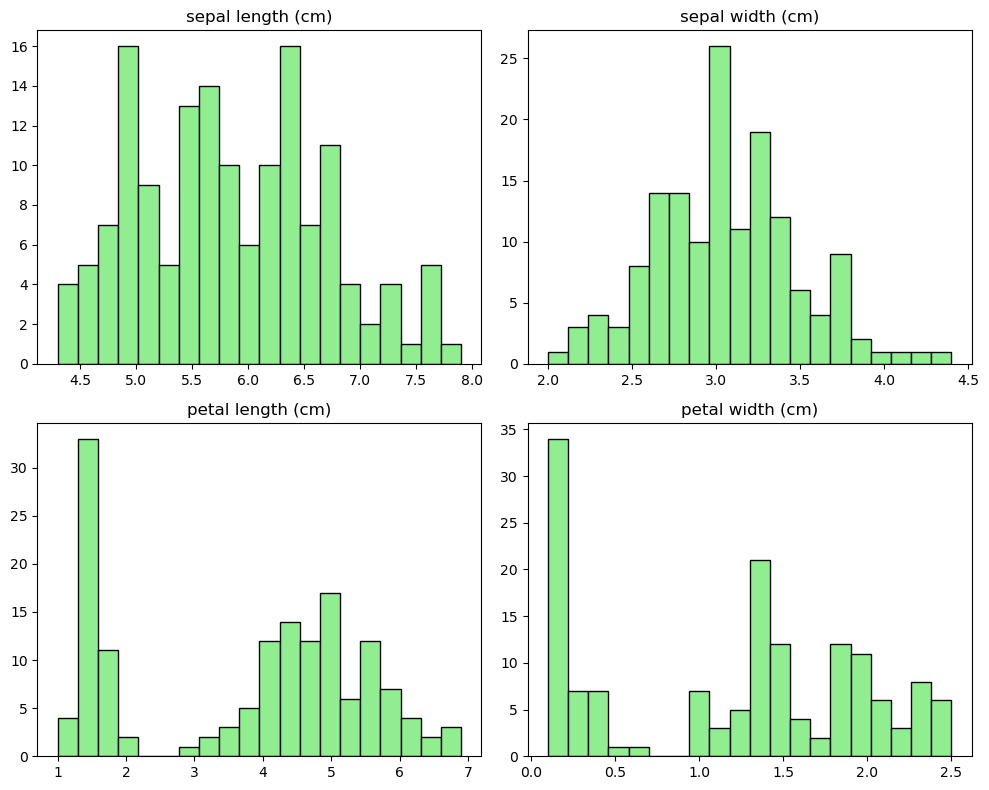

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for i, column in enumerate(df.columns[:4]):
    row = i // 2 #since it's a 2x2 graph we need to manually calculate the matrix rows and columns [0, 1]
                                                                                                 # [1, 0]
    col = i % 2
    axs[row, col].hist(df[column], bins=20, color='lightgreen', edgecolor='black')
    axs[row, col].set_title(column)

plt.tight_layout()
plt.show()

## Preprocessing

We split the data into train and test to "teach" our model about the data we are working with, so then we can predict our target values.

In [62]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling the data

We're going to use three different ML algorithms to model our data, evaluate them, and see which one performs best.

**Decision Tree**

In [104]:
decision_tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Now let's evaluate the model:

In [142]:
y_pred_tree = decision_tree.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred_tree))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_tree))

print("Classification Report: \n", classification_report(y_test, y_pred_tree)) 

Accuracy Score: 1.0
Confusion Matrix: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



With the Decision Tree algorithm, our model passed the accuracy test perfectly. 

**Random Forest**

In [120]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Let's evaluate the model:

In [144]:
y_pred_rf = forest.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_rf))

print("Classification Report: \n", classification_report(y_test, y_pred_rf)) 

Accuracy Score: 1.0
Confusion Matrix: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Again, our model seems to be working perfectly.

**SVM**

For the final model we will standardize our data, as Support Vector Machines tend to perform best on normalized features.

In [134]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),     # stardardizing the data
    ('svm', SVC())                    # SVM model
])

In [138]:
#Defining the hyperparameters we want to try
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

In [158]:
grid = GridSearchCV(pipeline, param_grid, cv=5) # cross validation with 5 folds

Here we trained and defined the best parameters for the model:

In [161]:
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}


In [163]:
y_pred_svm = grid.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred_svm))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_svm))

print("Classification Report: \n", classification_report(y_test, y_pred_svm))

Accuracy Score: 1.0
Confusion Matrix: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



As we can see, all of our models achieved perfect results. As previously mentioned, the Iris dataset is very well-constructed and clean, which naturally leads to high performance scores.